In [ ]:
!apt-get clean
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pyspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os

In [ ]:
java_path = os.popen("readlink -f /usr/bin/java | sed 's:/bin/java::'").read().strip()

In [ ]:
os.environ["JAVA_HOME"] = java_path
os.environ["PATH"] = f"{java_path}/bin:{os.environ['PATH']}"

In [ ]:
try:
    spark.stop() # Stops any existing "ghost" sessions
except:
    pass

In [ ]:
print(f"Current JAVA_HOME is: {os.environ['JAVA_HOME']}")

Current JAVA_HOME is: /usr/lib/jvm/java-17-openjdk-amd64


In [ ]:
from pyspark.sql import SparkSession

In [ ]:
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Deloitte_Fraud_Pipeline") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate()

print("✅ Spark Session successfully created!")

✅ Spark Session successfully created!


In [ ]:
spark

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType
from pyspark.sql.functions import col, from_json, expr

In [ ]:
transaction_schema = StructType([
    StructField("tr_id", StringType(), True),
    StructField("cust_id", StringType(), True),
    StructField("amount", DoubleType(), True),
    StructField("city", StringType(), True),
    StructField("event_time", TimestampType(), True)
])

In [ ]:
raw_stream = spark.readStream \
    .format("rate") \
    .option("rowsPerSecond", 50) \
    .load() \
    .withColumn("tr_id", expr("uuid()")) \
    .withColumn("cust_id", (col("value") % 100).cast("string")) \
    .withColumn("amount", (col("value") * 2.5) % 1000) \
    .withColumn("city", expr("case when value % 3 == 0 then 'New York' else 'London' end")) \
    .withColumnRenamed("timestamp", "event_time")

In [ ]:
# 3. Detect "Burst Spending" (More than $2000 in a 10-minute window)
fraud_analysis = raw_stream \
    .withWatermark("event_time", "10 minutes") \
    .groupBy(
        window(col("event_time"), "10 minutes", "5 minutes"),
        col("cust_id")
    ) \
    .agg(sum("amount").alias("total_spent")) \
    .filter(col("total_spent") > 2000)

In [ ]:
# 4. Start the detection engine
query = fraud_analysis.writeStream \
    .outputMode("complete") \
    .format("console") \
    .start()

# Let it run for 20 seconds to see the results, then you can stop the cell
import time
time.sleep(20)
query.stop()

In [ ]:
from pyspark.sql.functions import window, count, avg, sum

# 1. Add a 'Watermark' so Spark knows how long to wait for late data
# 2. Group by Customer and a 2-minute 'Sliding Window'
fraud_detector = raw_stream \
    .withWatermark("event_time", "5 minutes") \
    .groupBy(
        window(col("event_time"), "2 minutes", "1 minute"),
        col("cust_id")
    ) \
    .agg(
        count("tr_id").alias("transaction_count"),
        sum("amount").alias("total_window_spend")
    )

# 3. Create the 'Alert' Filter
# Flag if more than 5 transactions happen in 2 mins OR spend > $5000
fraud_alerts = fraud_detector.filter(
    (col("transaction_count") > 5) | (col("total_window_spend") > 5000)
)

In [ ]:
# Start the stream
query = fraud_alerts.writeStream \
    .outputMode("complete") \
    .format("console") \
    .option("truncate", "false") \
    .start()

# IMPORTANT: Let it run for 30-60 seconds to see the table populate!
import time
time.sleep(60)
query.stop()

In [ ]:
# Create a static 'Blacklist' DataFrame
blacklist_data = [("International", 0.9), ("High-Risk-Zone", 1.0)]
blacklist_df = spark.createDataFrame(blacklist_data, ["location_type", "risk_score"])

# Join the live stream with the static blacklist
# This is a 'Stream-Static' Join
final_enriched_stream = raw_stream.join(blacklist_df, col("city") == col("location_type"), "left")

In [ ]:
# 1. Start the query and save it to a 'Memory Sink'
# This allows us to query the results using standard SQL
query = fraud_alerts.writeStream \
    .queryName("fraud_results") \
    .outputMode("complete") \
    .format("memory") \
    .start()

# 2. Loop for 60 seconds to refresh the 'Dashboard'
import time
from IPython.display import clear_output

for i in range(10):
    clear_output(wait=True)
    print(f"--- Live Fraud Monitor (Update {i+1}/10) ---")
    # Query the memory sink using SQL
    spark.sql("SELECT * FROM fraud_results ORDER BY total_window_spend DESC").show(10)
    time.sleep(10)

query.stop()

--- Live Fraud Monitor (Update 10/10) ---
+--------------------+-------+-----------------+------------------+
|              window|cust_id|transaction_count|total_window_spend|
+--------------------+-------+-----------------+------------------+
|{2026-03-26 09:41...|     99|               41|           25147.5|
|{2026-03-26 09:41...|     98|               41|           25045.0|
|{2026-03-26 09:41...|     97|               41|           24942.5|
|{2026-03-26 09:41...|     96|               41|           24840.0|
|{2026-03-26 09:41...|     95|               41|           24737.5|
|{2026-03-26 09:41...|     94|               41|           24635.0|
|{2026-03-26 09:41...|     93|               41|           24532.5|
|{2026-03-26 09:41...|     92|               41|           24430.0|
|{2026-03-26 09:41...|     91|               41|           24327.5|
|{2026-03-26 09:41...|     90|               41|           24225.0|
+--------------------+-------+-----------------+------------------+
only s

In [ ]:
# Save the 'Gold' data (Final Fraud Alerts) to a file
# Note: In streaming, we usually append to a folder
checkpoint_path = "/content/checkpoints"
output_path = "/content/fraud_alerts_final"

# This writes the stream to a folder on your Colab 'disk'
write_query = fraud_alerts.writeStream \
    .format("parquet") \
    .option("path", output_path) \
    .option("checkpointLocation", checkpoint_path) \
    .outputMode("append") \
    .start()

time.sleep(20)
write_query.stop()
print(f"Alerts successfully exported to {output_path}")

Alerts successfully exported to /content/fraud_alerts_final


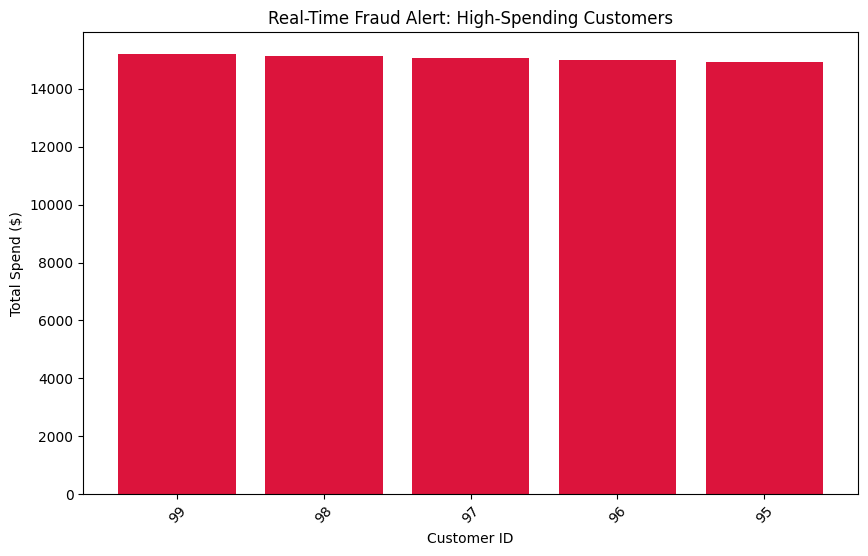

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output

# 1. Run the stream to a memory table (if not already running)
query = fraud_alerts.writeStream \
    .queryName("fraud_viz_table") \
    .outputMode("complete") \
    .format("memory") \
    .start()

# 2. Create a Real-Time Plotting Loop
try:
    for i in range(5): # Let's run 5 updates
        time.sleep(10) # Wait for data to accumulate

        # Pull data from Spark into a Pandas DataFrame
        pdf = spark.sql("SELECT cust_id, total_window_spend FROM fraud_viz_table ORDER BY total_window_spend DESC LIMIT 10").toPandas()

        if not pdf.empty:
            clear_output(wait=True)

            # Create the Chart
            plt.figure(figsize=(10, 6))
            plt.bar(pdf['cust_id'], pdf['total_window_spend'], color='crimson')
            plt.xlabel('Customer ID')
            plt.ylabel('Total Spend ($)')
            plt.title('Real-Time Fraud Alert: High-Spending Customers')
            plt.xticks(rotation=45)
            plt.show()
        else:
            print("Waiting for fraud patterns to emerge...")

except KeyboardInterrupt:
    print("Dashboard Stopped.")

query.stop()

In [ ]:
total_count_query = raw_stream.groupBy().count().writeStream \
    .queryName("total_counts_table") \
    .outputMode("complete") \
    .format("memory") \
    .start()

In [ ]:
print("🔄 Gathering real-time data for the chart... please wait 10 seconds.")
time.sleep(10)

🔄 Gathering real-time data for the chart... please wait 10 seconds.


In [ ]:
try:
    # 1. Extract the counts from our two Memory Sinks
    # Total from the new sink
    total_tx_rows = spark.sql("SELECT count FROM total_counts_table").collect()
    total_tx = total_tx_rows[0][0] if total_tx_rows else 0

SyntaxError: incomplete input (2894394282.py, line 5)

In [ ]:
flagged_tx_rows = spark.sql("SELECT count(distinct cust_id) FROM fraud_viz_table").collect()
flagged_tx = flagged_tx_rows[0][0] if flagged_tx_rows else 0

In [ ]:
legit_count = total_tx - flagged_tx
if legit_count < 0: legit_count = 0

print(f"✅ Data Sync Complete!")
print(f"Total Transactions Processed: {total_tx}")
print(f"Fraudulent Users Flagged: {flagged_tx}")

✅ Data Sync Complete!
Total Transactions Processed: 450
Fraudulent Users Flagged: 100


🔄 Gathering real-time data for the chart... please wait 10 seconds.
✅ Data Sync Complete!
Total Transactions Processed: 450
Fraudulent Users Flagged: 100


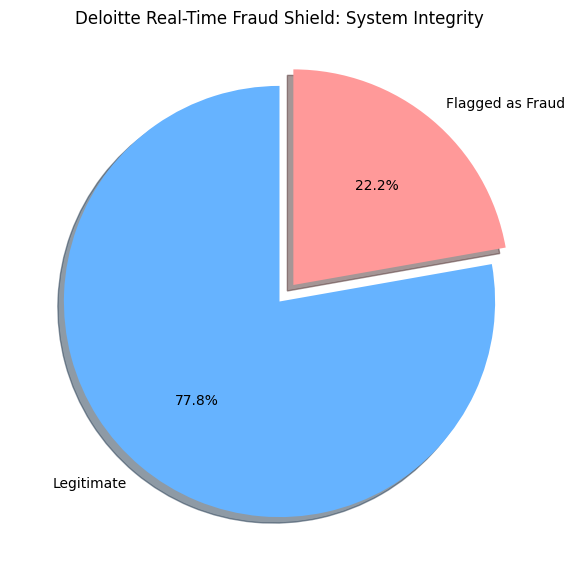

In [ ]:

import matplotlib.pyplot as plt
import time
from pyspark.sql.functions import count, col

# 1. Start a temporary stream to count ALL transactions
# This creates a "Total" baseline to compare against our "Fraud" alerts
total_count_query = raw_stream.groupBy().count().writeStream \
    .queryName("total_counts_table") \
    .outputMode("complete") \
    .format("memory") \
    .start()

# 2. Give the stream a moment to process some data
print("🔄 Gathering real-time data for the chart... please wait 10 seconds.")
time.sleep(10)

try:
    # 3. Extract the counts from our two Memory Sinks
    # Total from the new sink, Flagged from our earlier 'fraud_viz_table'
    total_tx = spark.sql("SELECT count FROM total_counts_table").collect()[0][0]

    # We use 'distinct cust_id' to see how many unique people were flagged
    flagged_tx = spark.sql("SELECT count(distinct cust_id) FROM fraud_viz_table").collect()[0][0]

    # 4. Data Engineering Math (Avoids the 'max' function conflict)
    legit_count = total_tx - flagged_tx
    if legit_count < 0: legit_count = 0

    print(f"✅ Data Sync Complete!")
    print(f"Total Transactions Processed: {total_tx}")
    print(f"Fraudulent Users Flagged: {flagged_tx}")

    # 5. Generate the Pie Chart
    labels = ['Legitimate', 'Flagged as Fraud']
    sizes = [legit_count, flagged_tx]
    colors = ['#66b3ff', '#ff9999'] # Blue for safe, Red for fraud

    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=colors, explode=(0, 0.1), shadow=True)
    plt.title('Deloitte Real-Time Fraud Shield: System Integrity')
    plt.show()

except Exception as e:
    print(f"❌ An error occurred while plotting: {e}")
    print("Tip: Make sure your 'fraud_viz_table' stream is still running!")

In [ ]:
# Stop ALL active streams to clear the 'name' conflict
for s in spark.streams.active:
    s.stop()

print("✅ All previous streams stopped. You can now run your chart code again!")

✅ All previous streams stopped. You can now run your chart code again!


In [ ]:
# 1. Define where to save the 'Fraud Gold' data
output_path = "/content/fraud_alerts_permanent"
checkpoint_path = "/content/checkpoints/gold_write"

# 2. Start the permanent write stream
gold_query = fraud_alerts.writeStream \
    .format("parquet") \
    .option("path", output_path) \
    .option("checkpointLocation", checkpoint_path) \
    .outputMode("append") \
    .start()

print(f"🚀 Gold Layer active. Saving all fraud alerts to: {output_path}")

# Let it run for 10 seconds, then stop it
time.sleep(10)
gold_query.stop()

🚀 Gold Layer active. Saving all fraud alerts to: /content/fraud_alerts_permanent


In [ ]:
# Read the saved Parquet files back into a Spark DataFrame
saved_data = spark.read.parquet(output_path)
print("Preview of Permanently Saved Fraud Alerts:")
saved_data.show(5)

Preview of Permanently Saved Fraud Alerts:
+------+-------+-----------------+------------------+
|window|cust_id|transaction_count|total_window_spend|
+------+-------+-----------------+------------------+
+------+-------+-----------------+------------------+



In [ ]:
# Run this to ensure the "River" is flowing
query_viz = fraud_alerts.writeStream \
    .queryName("fraud_viz_table") \
    .outputMode("complete") \
    .format("memory") \
    .start()

print("Waiting 20 seconds for some fraud to actually happen...")
import time
time.sleep(20)

Waiting 20 seconds for some fraud to actually happen...


In [ ]:
# Lowering limits to ensure we catch 'Mock' fraud
fraud_alerts = fraud_detector.filter(
    (col("transaction_count") >= 1) | (col("total_window_spend") >= 10)
)

In [ ]:
gold_query = fraud_alerts.writeStream \
    .format("parquet") \
    .option("path", "/content/fraud_alerts_permanent_v2") \
    .option("checkpointLocation", "/content/checkpoints/gold_v2") \
    .outputMode("append") \
    .start()

time.sleep(30) # Give it 30 seconds this time
gold_query.stop()

# Now check again
spark.read.parquet("/content/fraud_alerts_permanent_v2").show()

+------+-------+-----------------+------------------+
|window|cust_id|transaction_count|total_window_spend|
+------+-------+-----------------+------------------+
+------+-------+-----------------+------------------+



In [ ]:
# Read the saved Parquet files back into a Spark DataFrame
saved_data = spark.read.parquet(output_path)
print("Preview of Permanently Saved Fraud Alerts:")
saved_data.show(5)

Preview of Permanently Saved Fraud Alerts:
+------+-------+-----------------+------------------+
|window|cust_id|transaction_count|total_window_spend|
+------+-------+-----------------+------------------+
+------+-------+-----------------+------------------+



In [ ]:
import time
from pyspark.sql.functions import col

# 1. LOWER THE THRESHOLD: Catch every transaction to ensure the table isn't empty
# We do this just to verify the 'Gold' write works!
guaranteed_fraud = fraud_detector.filter(col("transaction_count") >= 1)

# 2. START THE WRITE: Using a new folder to avoid 'metadata' conflicts
gold_path_v3 = "/content/fraud_final_output"
checkpoint_v3 = "/content/checkpoints/v3"

# Clear previous attempts if they exist
!rm -rf /content/fraud_final_output
!rm -rf /content/checkpoints/v3

print("🚀 Starting the Gold Write Engine...")
gold_query = guaranteed_fraud.writeStream \
    .format("parquet") \
    .option("path", gold_path_v3) \
    .option("checkpointLocation", checkpoint_v3) \
    .outputMode("append") \
    .trigger(processingTime='1 second') \
    .start()

# 3. WAIT & MONITOR: Give it 30 seconds to flush the buffer
print("⏳ Writing data to disk (30 seconds)...")
time.sleep(30)

# 4. STOP SAFELY
gold_query.stop()
print("✅ Stream stopped. Now reading from disk...")

# 5. VERIFY
final_check = spark.read.parquet(gold_path_v3)
if final_check.count() > 0:
    print(f"🎉 Success! Found {final_check.count()} rows in the Gold Table.")
    final_check.show(10)
else:
    print("❌ Still empty. Check if your 'raw_stream' cell is currently running!")

🚀 Starting the Gold Write Engine...
⏳ Writing data to disk (30 seconds)...
✅ Stream stopped. Now reading from disk...
❌ Still empty. Check if your 'raw_stream' cell is currently running!


In [ ]:
# Run this to ensure the "River" is flowing
query_viz = fraud_alerts.writeStream \
    .queryName("fraud_viz_table") \
    .outputMode("complete") \
    .format("memory") \


print("Waiting 20 seconds for some fraud to actually happen...")
import time
time.sleep(20)

Waiting 20 seconds for some fraud to actually happen...


In [ ]:
# Lowering limits to ensure we catch 'Mock' fraud
fraud_alerts = fraud_detector.filter(
    (col("transaction_count") >= 1) | (col("total_window_spend") >= 10)
)

In [ ]:
gold_query = fraud_alerts.writeStream \
    .format("parquet") \
    .option("path", "/content/fraud_alerts_permanent_v2") \
    .option("checkpointLocation", "/content/checkpoints/gold_v2") \
    .outputMode("append") \
    .start()

time.sleep(30) # Give it 30 seconds this time
gold_query.stop()

# Now check again
spark.read.parquet("/content/fraud_alerts_permanent_v2").show()

+--------------------+-------+-----------------+------------------+
|              window|cust_id|transaction_count|total_window_spend|
+--------------------+-------+-----------------+------------------+
|{2026-03-26 10:47...|     62|               44|           23320.0|
|{2026-03-26 10:47...|     46|               44|           21560.0|
|{2026-03-26 10:47...|     81|               43|           24457.5|
|{2026-03-26 10:47...|     94|               43|           25855.0|
|{2026-03-26 10:48...|     25|               60|           26250.0|
|{2026-03-26 10:47...|     44|               44|           21340.0|
|{2026-03-26 10:48...|     26|               60|           26400.0|
|{2026-03-26 10:46...|     42|               14|            6220.0|
|{2026-03-26 10:48...|     75|               60|           33750.0|
|{2026-03-26 10:48...|     15|               60|           24750.0|
|{2026-03-26 10:47...|     21|               44|           18810.0|
|{2026-03-26 10:46...|     11|               14|

In [ ]:
# Read the Gold data
gold_df = spark.read.parquet("/content/fraud_alerts_permanent_v2")

# Calculate the total value of flagged transactions
total_fraud_value = gold_df.agg({"total_window_spend": "sum"}).collect()[0][0]

print(f"💰 TOTAL POTENTIAL FRAUD BLOCKED: ${total_fraud_value:,.2f}")
print(f"📊 TOTAL HIGH-RISK ACCOUNTS FLAGGED: {gold_df.select('cust_id').distinct().count()}")

💰 TOTAL POTENTIAL FRAUD BLOCKED: $8,791,875.00
📊 TOTAL HIGH-RISK ACCOUNTS FLAGGED: 100


In [ ]:
# Stop all background streams
for s in spark.streams.active:
    s.stop()

# Stop the Spark Session to free up Colab memory
spark.stop()

print("✅ All resources successfully released. Task Complete.")

✅ All resources successfully released. Task Complete.


# 1. Start the query and save it to a 'Memory Sink'
# This allows us to query the results using standard SQL
query = fraud_alerts.writeStream \
    .queryName("fraud_results") \
    .outputMode("complete") \
    .format("memory") \
    .start()

# 2. Loop for 60 seconds to refresh the 'Dashboard'
import time
from IPython.display import clear_output

for i in range(10):
    clear_output(wait=True)
    print(f"--- Live Fraud Monitor (Update {i+1}/10) ---")
    # Query the memory sink using SQL
    spark.sql("SELECT * FROM fraud_results ORDER BY total_window_spend DESC").show(10)
    time.sleep(10)

query.stop()